In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import gc
import torch

In [ ]:

# pretrained
x_train_tfidf = csr_matrix(np.load('x_train_tfidf.npy'))  # convert back to sparse
x_test_tfidf  = csr_matrix(np.load('x_test_tfidf.npy'))
x_train_w2v   = np.load('x_train_w2v.npy')
x_test_w2v    = np.load('x_test_w2v.npy')
x_train_sbert = np.load('x_train_sbert.npy')
x_test_sbert  = np.load('x_test_sbert.npy')
x_train_bert  = np.load('x_train_bert.npy')
x_test_bert   = np.load('x_test_bert.npy')
x_train_t5    = np.load('x_train_t5.npy')
x_test_t5     = np.load('x_test_t5.npy')
x_train_xlm   = np.load('x_train_xlm.npy')
x_test_xlm    = np.load('x_test_xlm.npy')
x_train_unix  = np.load('x_train_unix.npy')
x_test_unix   = np.load('x_test_unix.npy')

# finetuned
x_train_bert_ft  = np.load('x_train_bert_ft.npy')
x_test_bert_ft   = np.load('x_test_bert_ft.npy')
x_train_t5_ft    = np.load('x_train_t5_ft.npy')
x_test_t5_ft     = np.load('x_test_t5_ft.npy')
x_train_xlm_ft   = np.load('x_train_xlm_ft.npy')
x_test_xlm_ft    = np.load('x_test_xlm_ft.npy')
x_train_unix_ft  = np.load('x_train_unix_ft.npy')
x_test_unix_ft   = np.load('x_test_unix_ft.npy')

gc.collect()
torch.cuda.empty_cache()
print("All embeddings loaded!")


All embeddings loaded!


# Load Data

In [ ]:
df = pd.read_csv('data1300.csv')
print(df['Label'].value_counts())
df.head()

Label
Fact        722
Non-Fact    616
Name: count, dtype: int64


,Doc,Label
0,There are plenty of hosting providers to choos...,Non-Fact
1,"We always want services which are the fastest,...",Non-Fact
2,Shortly - we want the best and the most reason...,Non-Fact
3,It is obvious that people want to get the best...,Non-Fact
4,You should also keep in mind that bigger price...,Non-Fact


# Add Length Column

In [ ]:
l_df = df.copy()
l_df['doc_length'] = l_df['Doc'].astype(str).apply(lambda x: len(x.split()))
l_df.head()

,Doc,Label,doc_length
0,There are plenty of hosting providers to choos...,Non-Fact,11
1,"We always want services which are the fastest,...",Non-Fact,17
2,Shortly - we want the best and the most reason...,Non-Fact,10
3,It is obvious that people want to get the best...,Non-Fact,15
4,You should also keep in mind that bigger price...,Non-Fact,13


# OG Plot

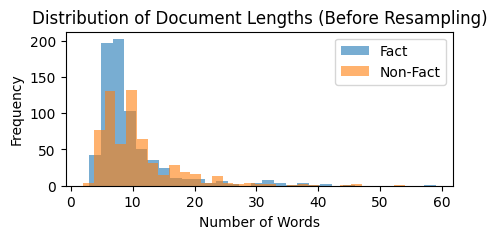

In [ ]:
fact_lengths = l_df[l_df['Label'] == 'Fact']['doc_length']
nonfact_lengths = l_df[l_df['Label'] == 'Non-Fact']['doc_length']

plt.figure(figsize=(5, 2))
plt.hist(fact_lengths, bins=30, alpha=0.6, label='Fact')
plt.hist(nonfact_lengths, bins=30, alpha=0.6, label='Non-Fact')
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Document Lengths (Before Resampling)")
plt.legend()
plt.show()

# Resample to fix bias

In [ ]:
bins = [0, 5, 10, 15, 20, 30, np.inf]
bin_labels = ['0-5', '6-10', '11-15', '16-20', '21-30', '30+']
l_df['length_bin'] = pd.cut(l_df['doc_length'], bins=bins, labels=bin_labels)

facts = l_df[l_df['Label'] == 'Fact']
non_facts = l_df[l_df['Label'] == 'Non-Fact']

resampled_facts = []
for b in bin_labels:
    fact_bin = facts[facts['length_bin'] == b]
    non_fact_bin = non_facts[non_facts['length_bin'] == b]
    target = len(non_fact_bin)
    if len(fact_bin) == 0 or target == 0:
        continue
    resampled_facts.append(
        fact_bin.sample(n=min(len(fact_bin), target), random_state=42)
    )

l_df = pd.concat(resampled_facts + [non_facts]).sample(frac=1, random_state=42).reset_index(drop=True)

print("After resampling:")
print(l_df['Label'].value_counts())

After resampling:
Label
Non-Fact    616
Fact        571
Name: count, dtype: int64


# Plot After

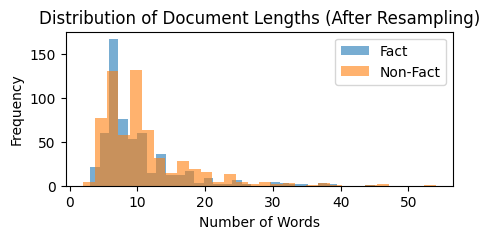

In [ ]:
fact_lengths_new = l_df[l_df['Label'] == 'Fact']['doc_length']
nonfact_lengths_new = l_df[l_df['Label'] == 'Non-Fact']['doc_length']

plt.figure(figsize=(5, 2))
plt.hist(fact_lengths_new, bins=30, alpha=0.6, label='Fact')
plt.hist(nonfact_lengths_new, bins=30, alpha=0.6, label='Non-Fact')
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Document Lengths (After Resampling)")
plt.legend()
plt.show()

In [ ]:
l_df = l_df.drop('doc_length', axis=1)
l_df = l_df.drop('length_bin', axis=1)
l_df.head()

,Doc,Label
0,He has acted in more than 350 films.,Fact
1,Technology is becoming more important in every...,Non-Fact
2,There is a general shift toward adopting tools...,Non-Fact
3,The Miss World organization released videos.,Fact
4,People tend to rely on tools and systems that ...,Non-Fact


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(l_df, test_size=0.2, random_state=42, stratify=l_df['Label'])

y_train = train_df['Label'].map({'Fact': 1, 'Non-Fact': 0})
y_test  = test_df['Label'].map({'Fact': 1, 'Non-Fact': 0})

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
print(f"Train label dist:\n{y_train.value_counts()}")

Train size: 949 | Test size: 238
Train label dist:
Label
0    492
1    457
Name: count, dtype: int64


# Preprocessing & Word Embeddings

In [ ]:
#!pip install gensim

In [ ]:
'''
from sentence_transformers import SentenceTransformer
from gensim.models import Word2Vec

# --- Embedding 1: TF-IDF ---
def get_tfidf_embeddings(train_df, test_df):
    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=1000,
        ngram_range=(1, 2),
        min_df=0.01
    )
    X_train = tfidf.fit_transform(train_df['Doc'])
    X_test  = tfidf.transform(test_df['Doc'])
    return X_train, X_test

# --- Embedding 2: Word2Vec ---
def get_word2vec_embeddings(train_df, test_df, vector_size=100):
    def doc_to_vector(doc, model):
        words = doc.lower().split()
        vectors = [model.wv[w] for w in words if w in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

    tokenized = [doc.lower().split() for doc in train_df['Doc']]
    w2v = Word2Vec(tokenized, vector_size=vector_size, window=5, min_count=1, workers=4)

    X_train = np.array([doc_to_vector(doc, w2v) for doc in train_df['Doc']])
    X_test  = np.array([doc_to_vector(doc, w2v) for doc in test_df['Doc']])
    return X_train, X_test
    '''

"\nfrom sentence_transformers import SentenceTransformer\nfrom gensim.models import Word2Vec\n\n# --- Embedding 1: TF-IDF ---\ndef get_tfidf_embeddings(train_df, test_df):\n    tfidf = TfidfVectorizer(\n        stop_words='english',\n        max_features=1000,\n        ngram_range=(1, 2),\n        min_df=0.01\n    )\n    X_train = tfidf.fit_transform(train_df['Doc'])\n    X_test  = tfidf.transform(test_df['Doc'])\n    return X_train, X_test\n\n# --- Embedding 2: Word2Vec ---\ndef get_word2vec_embeddings(train_df, test_df, vector_size=100):\n    def doc_to_vector(doc, model):\n        words = doc.lower().split()\n        vectors = [model.wv[w] for w in words if w in model.wv]\n        return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)\n\n    tokenized = [doc.lower().split() for doc in train_df['Doc']]\n    w2v = Word2Vec(tokenized, vector_size=vector_size, window=5, min_count=1, workers=4)\n\n    X_train = np.array([doc_to_vector(doc, w2v) for doc in train_df['D

# New Embeddings Pretrained

In [ ]:
'''
from sentence_transformers import SentenceTransformer
from transformers import (
    BertTokenizer, BertModel,
    T5Tokenizer, T5EncoderModel,
    XLMRobertaTokenizer, XLMRobertaModel,
    AutoTokenizer, AutoModel
)
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── CLS token extraction (BERT, XLM, UniXcoder) ──────────────────────────────
def cls_pool(model, tokenizer, texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            output = model(**encoded)
        embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()  # CLS token
        all_embeddings.append(embeddings)
    return np.vstack(all_embeddings)

# ── Attention-masked mean pooling (T5) ───────────────────────────────────────
def attention_mean_pool(model, tokenizer, texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            output = model(**encoded)
        attention_mask = encoded['attention_mask'].unsqueeze(-1)
        embeddings = (output.last_hidden_state * attention_mask).sum(dim=1) / attention_mask.sum(dim=1)
        all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

# ── 1. SBERT (pretrained) ────────────────────────────────────────────────────
def get_sbert_embeddings(train_df, test_df, model_name='all-MiniLM-L6-v2'):
    sbert = SentenceTransformer(model_name)
    X_train = sbert.encode(list(train_df['Doc']), show_progress_bar=True, batch_size=32)
    X_test  = sbert.encode(list(test_df['Doc']),  show_progress_bar=True, batch_size=32)
    return X_train, X_test

# ── 2. BERT (pretrained) ─────────────────────────────────────────────────────
def get_bert_embeddings(train_df, test_df):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model     = BertModel.from_pretrained('bert-base-uncased').to(device)
    model.eval()
    X_train = cls_pool(model, tokenizer, list(train_df['Doc']))
    X_test  = cls_pool(model, tokenizer, list(test_df['Doc']))
    return X_train, X_test

# ── 3. T5 (pretrained) ───────────────────────────────────────────────────────
def get_t5_embeddings(train_df, test_df):
    tokenizer = T5Tokenizer.from_pretrained('t5-base')
    model     = T5EncoderModel.from_pretrained('t5-base').to(device)
    model.eval()
    X_train = attention_mean_pool(model, tokenizer, list(train_df['Doc']))
    X_test  = attention_mean_pool(model, tokenizer, list(test_df['Doc']))
    return X_train, X_test

# ── 4. XLM-RoBERTa (pretrained) ──────────────────────────────────────────────
def get_xlm_embeddings(train_df, test_df):
    tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
    model     = XLMRobertaModel.from_pretrained('xlm-roberta-base').to(device)
    model.eval()
    X_train = cls_pool(model, tokenizer, list(train_df['Doc']))
    X_test  = cls_pool(model, tokenizer, list(test_df['Doc']))
    return X_train, X_test

# ── 5. UniXcoder (pretrained) ─────────────────────────────────────────────────
def get_unixcoder_embeddings(train_df, test_df):
    tokenizer = AutoTokenizer.from_pretrained('microsoft/unixcoder-base')
    model     = AutoModel.from_pretrained('microsoft/unixcoder-base').to(device)
    model.eval()
    X_train = cls_pool(model, tokenizer, list(train_df['Doc']))
    X_test  = cls_pool(model, tokenizer, list(test_df['Doc']))
    return X_train, X_test
    '''

'\nfrom sentence_transformers import SentenceTransformer\nfrom transformers import (\n    BertTokenizer, BertModel,\n    T5Tokenizer, T5EncoderModel,\n    XLMRobertaTokenizer, XLMRobertaModel,\n    AutoTokenizer, AutoModel\n)\nimport torch\n\ndevice = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\nprint(f"Using device: {device}")\n\n# ── CLS token extraction (BERT, XLM, UniXcoder) ──────────────────────────────\ndef cls_pool(model, tokenizer, texts, batch_size=32):\n    all_embeddings = []\n    for i in range(0, len(texts), batch_size):\n        batch = texts[i:i+batch_size]\n        encoded = tokenizer(batch, padding=True, truncation=True,\n                            max_length=128, return_tensors=\'pt\').to(device)\n        with torch.no_grad():\n            output = model(**encoded)\n        embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()  # CLS token\n        all_embeddings.append(embeddings)\n    return np.vstack(all_embeddings)\n\n# ── Attention-m

# Finetuned Embeddings

In [ ]:
'''
from torch.utils.data import Dataset, DataLoader
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(list(texts), padding=True, truncation=True,
                                   max_length=max_length, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}, self.labels[idx]


def finetune_and_embed(model, tokenizer, train_df, test_df,
                       pool_strategy='cls', epochs=3, batch_size=16, lr=2e-5):
    class ClassifierHead(torch.nn.Module):
        def __init__(self, base, hidden_size):
            super().__init__()
            self.base = base
            self.classifier = torch.nn.Linear(hidden_size, 2)

        def forward(self, **inputs):
            labels = inputs.pop('labels', None)
            output = self.base(**inputs)
            # use correct pooling strategy per model
            if pool_strategy == 'cls':
                pooled = output.last_hidden_state[:, 0, :]
            else:  # attention mean pool for T5
                attention_mask = inputs['attention_mask'].unsqueeze(-1)
                pooled = (output.last_hidden_state * attention_mask).sum(dim=1) / attention_mask.sum(dim=1)
            logits = self.classifier(pooled)
            loss = None
            if labels is not None:
                loss = torch.nn.CrossEntropyLoss()(logits, labels)
            return loss, logits, pooled

    hidden_size = model.config.hidden_size
    clf         = ClassifierHead(model, hidden_size).to(device)

    dataset    = TextDataset(train_df['Doc'], y_train, tokenizer)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = AdamW(clf.parameters(), lr=lr)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=len(dataloader) * epochs
    )

    clf.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_inputs, batch_labels in dataloader:
            batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad()
            loss, _, _ = clf(labels=batch_labels, **batch_inputs)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(dataloader):.4f}")

    clf.eval()
    def extract(texts):
        all_embs = []
        for i in range(0, len(texts), batch_size):
            batch = list(texts[i:i+batch_size])
            encoded = tokenizer(batch, padding=True, truncation=True,
                                max_length=128, return_tensors='pt').to(device)
            with torch.no_grad():
                _, _, pooled = clf(labels=None, **encoded)
            all_embs.append(pooled.cpu().numpy())
        return np.vstack(all_embs)

    X_train = extract(train_df['Doc'])
    X_test  = extract(test_df['Doc'])
    return X_train, X_test


# ── Fine-tuned embedding getters ─────────────────────────────────────────────
def get_bert_finetuned(train_df, test_df):
    print("Fine-tuning BERT...")
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model     = BertModel.from_pretrained('bert-base-uncased').to(device)
    return finetune_and_embed(model, tokenizer, train_df, test_df, pool_strategy='cls')

def get_t5_finetuned(train_df, test_df):
    print("Fine-tuning T5...")
    tokenizer = T5Tokenizer.from_pretrained('t5-base')
    model     = T5EncoderModel.from_pretrained('t5-base').to(device)
    return finetune_and_embed(model, tokenizer, train_df, test_df, pool_strategy='attention_mean')

def get_xlm_finetuned(train_df, test_df):
    print("Fine-tuning XLM-RoBERTa...")
    tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
    model     = XLMRobertaModel.from_pretrained('xlm-roberta-base').to(device)
    return finetune_and_embed(model, tokenizer, train_df, test_df, pool_strategy='cls')

def get_unixcoder_finetuned(train_df, test_df):
    print("Fine-tuning UniXcoder...")
    tokenizer = AutoTokenizer.from_pretrained('microsoft/unixcoder-base')
    model     = AutoModel.from_pretrained('microsoft/unixcoder-base').to(device)
    return finetune_and_embed(model, tokenizer, train_df, test_df, pool_strategy='cls')
    '''

'\nfrom torch.utils.data import Dataset, DataLoader\nfrom transformers import get_linear_schedule_with_warmup\nfrom torch.optim import AdamW\n\nclass TextDataset(Dataset):\n    def __init__(self, texts, labels, tokenizer, max_length=128):\n        self.encodings = tokenizer(list(texts), padding=True, truncation=True,\n                                   max_length=max_length, return_tensors=\'pt\')\n        self.labels = torch.tensor(list(labels), dtype=torch.long)\n\n    def __len__(self):\n        return len(self.labels)\n\n    def __getitem__(self, idx):\n        return {k: v[idx] for k, v in self.encodings.items()}, self.labels[idx]\n\n\ndef finetune_and_embed(model, tokenizer, train_df, test_df,\n                       pool_strategy=\'cls\', epochs=3, batch_size=16, lr=2e-5):\n    class ClassifierHead(torch.nn.Module):\n        def __init__(self, base, hidden_size):\n            super().__init__()\n            self.base = base\n            self.classifier = torch.nn.Linear(hidden_s

# Embeddings Data Split

In [ ]:
'''
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(l_df, test_size=0.2, random_state=42)
y_train = train_df['Label'].map({'Fact': 1, 'Non-Fact': 0})
y_test  = test_df['Label'].map({'Fact': 1, 'Non-Fact': 0})

#pretrained
x_train_tfidf, x_test_tfidf = get_tfidf_embeddings(train_df, test_df)
x_train_w2v,   x_test_w2v   = get_word2vec_embeddings(train_df, test_df)
print("SBERT...")
x_train_sbert,    x_test_sbert    = get_sbert_embeddings(train_df, test_df)
print("BERT...")
x_train_bert,     x_test_bert     = get_bert_embeddings(train_df, test_df)
print("T5...")
x_train_t5,       x_test_t5       = get_t5_embeddings(train_df, test_df)
print("XLM...")
x_train_xlm,      x_test_xlm      = get_xlm_embeddings(train_df, test_df)
print("UniXcoder...")
x_train_unix,     x_test_unix     = get_unixcoder_embeddings(train_df, test_df)

print("\n=== Fine-tuned Embeddings ===")
x_train_bert_ft,  x_test_bert_ft  = get_bert_finetuned(train_df, test_df)
x_train_t5_ft,    x_test_t5_ft    = get_t5_finetuned(train_df, test_df)
x_train_xlm_ft,   x_test_xlm_ft   = get_xlm_finetuned(train_df, test_df)
'''

'\nfrom sklearn.model_selection import train_test_split\n\ntrain_df, test_df = train_test_split(l_df, test_size=0.2, random_state=42)\ny_train = train_df[\'Label\'].map({\'Fact\': 1, \'Non-Fact\': 0})\ny_test  = test_df[\'Label\'].map({\'Fact\': 1, \'Non-Fact\': 0})\n\n#pretrained\nx_train_tfidf, x_test_tfidf = get_tfidf_embeddings(train_df, test_df)\nx_train_w2v,   x_test_w2v   = get_word2vec_embeddings(train_df, test_df)\nprint("SBERT...")\nx_train_sbert,    x_test_sbert    = get_sbert_embeddings(train_df, test_df)\nprint("BERT...")\nx_train_bert,     x_test_bert     = get_bert_embeddings(train_df, test_df)\nprint("T5...")\nx_train_t5,       x_test_t5       = get_t5_embeddings(train_df, test_df)\nprint("XLM...")\nx_train_xlm,      x_test_xlm      = get_xlm_embeddings(train_df, test_df)\nprint("UniXcoder...")\nx_train_unix,     x_test_unix     = get_unixcoder_embeddings(train_df, test_df)\n\nprint("\n=== Fine-tuned Embeddings ===")\nx_train_bert_ft,  x_test_bert_ft  = get_bert_finetun

In [ ]:
'''
# pretrained
np.save('x_train_tfidf.npy', x_train_tfidf.toarray())  # tfidf is sparse so needs .toarray()
np.save('x_test_tfidf.npy',  x_test_tfidf.toarray())
np.save('x_train_w2v.npy',   x_train_w2v)
np.save('x_test_w2v.npy',    x_test_w2v)
np.save('x_train_sbert.npy', x_train_sbert)
np.save('x_test_sbert.npy',  x_test_sbert)
np.save('x_train_bert.npy',  x_train_bert)
np.save('x_test_bert.npy',   x_test_bert)
np.save('x_train_t5.npy',    x_train_t5)
np.save('x_test_t5.npy',     x_test_t5)
np.save('x_train_xlm.npy',   x_train_xlm)
np.save('x_test_xlm.npy',    x_test_xlm)
np.save('x_train_unix.npy',  x_train_unix)
np.save('x_test_unix.npy',   x_test_unix)
print("All pretrained embeddings saved!")

# finetuned
np.save('x_train_bert_ft.npy',  x_train_bert_ft)
np.save('x_test_bert_ft.npy',   x_test_bert_ft)
np.save('x_train_t5_ft.npy',    x_train_t5_ft)
np.save('x_test_t5_ft.npy',     x_test_t5_ft)
np.save('x_train_xlm_ft.npy',   x_train_xlm_ft)
np.save('x_test_xlm_ft.npy',    x_test_xlm_ft)
np.save('x_train_unix_ft.npy',  x_train_unix_ft)
np.save('x_test_unix_ft.npy',   x_test_unix_ft)
print("All finetuned embeddings saved!")
'''

'\n# pretrained\nnp.save(\'x_train_tfidf.npy\', x_train_tfidf.toarray())  # tfidf is sparse so needs .toarray()\nnp.save(\'x_test_tfidf.npy\',  x_test_tfidf.toarray())\nnp.save(\'x_train_w2v.npy\',   x_train_w2v)\nnp.save(\'x_test_w2v.npy\',    x_test_w2v)\nnp.save(\'x_train_sbert.npy\', x_train_sbert)\nnp.save(\'x_test_sbert.npy\',  x_test_sbert)\nnp.save(\'x_train_bert.npy\',  x_train_bert)\nnp.save(\'x_test_bert.npy\',   x_test_bert)\nnp.save(\'x_train_t5.npy\',    x_train_t5)\nnp.save(\'x_test_t5.npy\',     x_test_t5)\nnp.save(\'x_train_xlm.npy\',   x_train_xlm)\nnp.save(\'x_test_xlm.npy\',    x_test_xlm)\nnp.save(\'x_train_unix.npy\',  x_train_unix)\nnp.save(\'x_test_unix.npy\',   x_test_unix)\nprint("All pretrained embeddings saved!")\n\n# finetuned\nnp.save(\'x_train_bert_ft.npy\',  x_train_bert_ft)\nnp.save(\'x_test_bert_ft.npy\',   x_test_bert_ft)\nnp.save(\'x_train_t5_ft.npy\',    x_train_t5_ft)\nnp.save(\'x_test_t5_ft.npy\',     x_test_t5_ft)\nnp.save(\'x_train_xlm_ft.npy\',

In [ ]:
pretrained_embeddings = {
    'TF-IDF':     (x_train_tfidf, x_test_tfidf),
    'Word2Vec':   (x_train_w2v,   x_test_w2v),
    'SBERT':      (x_train_sbert, x_test_sbert),
    'BERT':       (x_train_bert,  x_test_bert),
    'T5':         (x_train_t5,    x_test_t5),
    'XLM':        (x_train_xlm,   x_test_xlm),
    'UniXcoder':  (x_train_unix,  x_test_unix),
}

finetuned_embeddings = {
    'BERT-FT':      (x_train_bert_ft,  x_test_bert_ft),
    'T5-FT':        (x_train_t5_ft,    x_test_t5_ft),
    'XLM-FT':       (x_train_xlm_ft,   x_test_xlm_ft),
    'UniXcoder-FT': (x_train_unix_ft,  x_test_unix_ft),
}

# Models

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform
import scipy.sparse as sp

def get_model_configs():
    return {
        'KNN': (
            KNeighborsClassifier(),
            {'n_neighbors': [3,5,7,9,11,13,15], 'weights': ['uniform','distance'], 'metric': ['euclidean','manhattan']}
        ),
        'Decision Tree': (
            DecisionTreeClassifier(random_state=42),
            {'max_depth': randint(3,15), 'min_samples_split': randint(2,10), 'min_samples_leaf': randint(1,5)}
        ),
        'Logistic Regression': (
            LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
            {'C': loguniform(1e-2, 1e2), 'penalty': ['l2'], 'solver': ['liblinear']}
        ),
        'SVM': (
            SVC(class_weight='balanced', random_state=42),
            {'C': loguniform(1e-2, 1e2), 'kernel': ['rbf','linear','poly','sigmoid'], 'gamma': ['scale','auto']}
        ),
        'XGBoost': (
            XGBClassifier(eval_metric='logloss', random_state=42),
            {'n_estimators': randint(50,300), 'max_depth': randint(2,8),
             'learning_rate': uniform(0.01,0.3), 'subsample': uniform(0.6,0.4),
             'colsample_bytree': uniform(0.6,0.4), 'scale_pos_weight': [1,1.5,2]}
        ),
        'LightGBM': (
            LGBMClassifier(verbose=-1, random_state=42),
            {'n_estimators': randint(50,300), 'max_depth': randint(2,8),
             'learning_rate': uniform(0.01,0.3), 'subsample': uniform(0.6,0.4),
             'colsample_bytree': uniform(0.6,0.4), 'class_weight': ['balanced', None]}
        ),

        'CatBoost': (
            CatBoostClassifier(verbose=0, random_state=42),
            {'iterations': randint(50,300), 'depth': randint(2,8),
             'learning_rate': uniform(0.01,0.3), 'l2_leaf_reg': uniform(1,9),
             'auto_class_weights': ['Balanced', 'SqrtBalanced']}
        ),
    }

def run_all_models(embeddings_dict, y_train, y_test):
    results = []

    for emb_name, (x_tr, x_te) in embeddings_dict.items():
        x_tr = x_tr.toarray() if sp.issparse(x_tr) else x_tr
        x_te = x_te.toarray() if sp.issparse(x_te) else x_te

        for model_name, (model, param_dist) in get_model_configs().items():

            print(f"\nRunning {model_name} | {emb_name}")

            search = RandomizedSearchCV(
                model,
                param_dist,
                n_iter=10,
                cv=3,
                scoring='f1_macro',
                n_jobs=-1,
                random_state=42
            )

            search.fit(x_tr, y_train)
            best = search.best_estimator_

            train_preds = best.predict(x_tr)
            test_preds  = best.predict(x_te)

            train_acc = round(accuracy_score(y_train, train_preds), 4)
            train_f1  = round(f1_score(y_train, train_preds, average='macro'), 4)
            test_acc  = round(accuracy_score(y_test, test_preds), 4)
            test_f1   = round(f1_score(y_test, test_preds, average='macro'), 4)

            # PRINT METRICS
            print(f"Embedding       : {emb_name}")
            print(f"Model           : {model_name}")
            print(f"Train Accuracy  : {train_acc}")
            print(f"Train F1 Score  : {train_f1}")
            print(f"Test Accuracy   : {test_acc}")
            print(f"Test F1 Score   : {test_f1}")
            print("-"*50)

            results.append({
                'Embedding': emb_name,
                'Model': model_name,
                'Train Accuracy': train_acc,
                'Train F1': train_f1,
                'Test Accuracy': test_acc,
                'Test F1': test_f1
            })

    return pd.DataFrame(results)

In [ ]:
print("=== Running models on Pretrained Embeddings ===")
pretrained_results_df = run_all_models(pretrained_embeddings, y_train, y_test)

print("\n=== Running models on Fine-tuned Embeddings ===")
finetuned_results_df = run_all_models(finetuned_embeddings, y_train, y_test)

=== Running models on Pretrained Embeddings ===

Running KNN | TF-IDF
Embedding       : TF-IDF
Model           : KNN
Train Accuracy  : 0.5774
Train F1 Score  : 0.5771
Test Accuracy   : 0.5042
Test F1 Score   : 0.5042
--------------------------------------------------

Running Decision Tree | TF-IDF
Embedding       : TF-IDF
Model           : Decision Tree
Train Accuracy  : 0.5933
Train F1 Score  : 0.5059
Test Accuracy   : 0.5462
Test F1 Score   : 0.4623
--------------------------------------------------

Running Logistic Regression | TF-IDF
Embedding       : TF-IDF
Model           : Logistic Regression
Train Accuracy  : 0.5922
Train F1 Score  : 0.5901
Test Accuracy   : 0.5546
Test F1 Score   : 0.55
--------------------------------------------------

Running SVM | TF-IDF
Embedding       : TF-IDF
Model           : SVM
Train Accuracy  : 0.705
Train F1 Score  : 0.7014
Test Accuracy   : 0.5294
Test F1 Score   : 0.5273
--------------------------------------------------

Running XGBoost | TF-I

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Embedding       : TF-IDF
Model           : LightGBM
Train Accuracy  : 0.569
Train F1 Score  : 0.5401
Test Accuracy   : 0.5252
Test F1 Score   : 0.4941
--------------------------------------------------

Running CatBoost | TF-IDF
Embedding       : TF-IDF
Model           : CatBoost
Train Accuracy  : 0.6955
Train F1 Score  : 0.6912
Test Accuracy   : 0.5168
Test F1 Score   : 0.5114
--------------------------------------------------

Running KNN | Word2Vec
Embedding       : Word2Vec
Model           : KNN
Train Accuracy  : 0.7545
Train F1 Score  : 0.7536
Test Accuracy   : 0.4916
Test F1 Score   : 0.4839
--------------------------------------------------

Running Decision Tree | Word2Vec
Embedding       : Word2Vec
Model           : Decision Tree
Train Accuracy  : 0.8388
Train F1 Score  : 0.8372
Test Accuracy   : 0.4832
Test F1 Score   : 0.4805
--------------------------------------------------

Running Logistic Regression | Word2Vec
Embedding       : Word2Vec
Model           : Logistic Regres

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Embedding       : Word2Vec
Model           : LightGBM
Train Accuracy  : 0.9705
Train F1 Score  : 0.9704
Test Accuracy   : 0.5168
Test F1 Score   : 0.5105
--------------------------------------------------

Running CatBoost | Word2Vec
Embedding       : Word2Vec
Model           : CatBoost
Train Accuracy  : 0.9874
Train F1 Score  : 0.9873
Test Accuracy   : 0.5168
Test F1 Score   : 0.5158
--------------------------------------------------

Running KNN | SBERT
Embedding       : SBERT
Model           : KNN
Train Accuracy  : 0.6143
Train F1 Score  : 0.6109
Test Accuracy   : 0.521
Test F1 Score   : 0.5161
--------------------------------------------------

Running Decision Tree | SBERT
Embedding       : SBERT
Model           : Decision Tree
Train Accuracy  : 0.7587
Train F1 Score  : 0.755
Test Accuracy   : 0.4664
Test F1 Score   : 0.4532
--------------------------------------------------

Running Logistic Regression | SBERT
Embedding       : SBERT
Model           : Logistic Regression
Train Ac

...

Embedding       : T5-FT
Model           : LightGBM
Train Accuracy  : 0.9884
Train F1 Score  : 0.9884
Test Accuracy   : 0.4748
Test F1 Score   : 0.4679
--------------------------------------------------

Running CatBoost | T5-FT
Embedding       : T5-FT
Model           : CatBoost
Train Accuracy  : 0.9262
Train F1 Score  : 0.9262
Test Accuracy   : 0.5084
Test F1 Score   : 0.508
--------------------------------------------------

Running KNN | XLM-FT
Embedding       : XLM-FT
Model           : KNN
Train Accuracy  : 0.9884
Train F1 Score  : 0.9884
Test Accuracy   : 0.479
Test F1 Score   : 0.4694
--------------------------------------------------

Running Decision Tree | XLM-FT
Embedding       : XLM-FT
Model           : Decision Tree
Train Accuracy  : 0.7692
Train F1 Score  : 0.7644
Test Accuracy   : 0.4454
Test F1 Score   : 0.4338
--------------------------------------------------

Running Logistic Regression | XLM-FT
Embedding       : XLM-FT
Model           : Logistic Regression
Train Accur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Embedding       : XLM-FT
Model           : LightGBM
Train Accuracy  : 0.9884
Train F1 Score  : 0.9884
Test Accuracy   : 0.4664
Test F1 Score   : 0.4594
--------------------------------------------------

Running CatBoost | XLM-FT
Embedding       : XLM-FT
Model           : CatBoost
Train Accuracy  : 0.9884
Train F1 Score  : 0.9884
Test Accuracy   : 0.5042
Test F1 Score   : 0.4972
--------------------------------------------------

Running KNN | UniXcoder-FT
Embedding       : UniXcoder-FT
Model           : KNN
Train Accuracy  : 0.7439
Train F1 Score  : 0.7433
Test Accuracy   : 0.5042
Test F1 Score   : 0.5033
--------------------------------------------------

Running Decision Tree | UniXcoder-FT
Embedding       : UniXcoder-FT
Model           : Decision Tree
Train Accuracy  : 0.863
Train F1 Score  : 0.8626
Test Accuracy   : 0.542
Test F1 Score   : 0.5384
--------------------------------------------------

Running Logistic Regression | UniXcoder-FT
Embedding       : UniXcoder-FT
Model     

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Embedding       : UniXcoder-FT
Model           : LightGBM
Train Accuracy  : 0.9884
Train F1 Score  : 0.9884
Test Accuracy   : 0.4874
Test F1 Score   : 0.4865
--------------------------------------------------

Running CatBoost | UniXcoder-FT
Embedding       : UniXcoder-FT
Model           : CatBoost
Train Accuracy  : 0.9884
Train F1 Score  : 0.9884
Test Accuracy   : 0.4538
Test F1 Score   : 0.4528
--------------------------------------------------


In [ ]:
print(pretrained_results_df)
print(finetuned_results_df)

    Embedding                Model  Train Accuracy  Train F1  Test Accuracy  \
0      TF-IDF                  KNN          0.5774    0.5771         0.5042   
1      TF-IDF        Decision Tree          0.5933    0.5059         0.5462   
2      TF-IDF  Logistic Regression          0.5922    0.5901         0.5546   
3      TF-IDF                  SVM          0.7050    0.7014         0.5294   
4      TF-IDF              XGBoost          0.6702    0.6681         0.5420   
5      TF-IDF             LightGBM          0.5690    0.5401         0.5252   
6      TF-IDF             CatBoost          0.6955    0.6912         0.5168   
7    Word2Vec                  KNN          0.7545    0.7536         0.4916   
8    Word2Vec        Decision Tree          0.8388    0.8372         0.4832   
9    Word2Vec  Logistic Regression          0.5142    0.5140         0.4958   
10   Word2Vec                  SVM          0.6691    0.6678         0.5084   
11   Word2Vec              XGBoost          0.9874  

# Excel

In [ ]:
def format_results(df):
    df = df.set_index(['Model', 'Embedding'])
    df.columns = pd.MultiIndex.from_tuples([
        ('Train', 'Accuracy'),
        ('Train', 'F1 Score'),
        ('Test',  'Accuracy'),
        ('Test',  'F1 Score'),
    ])
    return df

pretrained_formatted = format_results(pretrained_results_df.copy())
finetuned_formatted  = format_results(finetuned_results_df.copy())

# Results for BERT, T5, XLM, UniXcoder only (pretrained + finetuned combined)
transformer_embeddings = ['BERT', 'T5', 'XLM', 'UniXcoder',
                          'BERT-FT', 'T5-FT', 'XLM-FT', 'UniXcoder-FT']
all_results_df     = pd.concat([pretrained_results_df, finetuned_results_df])
transformer_results_df = all_results_df[all_results_df['Embedding'].isin(transformer_embeddings)]
transformer_formatted  = format_results(transformer_results_df.copy())

print("Pretrained Results:")
display(pretrained_formatted)

print("\nFine-tuned Results:")
display(finetuned_formatted)

Pretrained Results:


Train              Test         
                              Accuracy F1 Score Accuracy F1 Score
Model               Embedding                                    
KNN                 TF-IDF      0.5774   0.5771   0.5042   0.5042
Decision Tree       TF-IDF      0.5933   0.5059   0.5462   0.4623
Logistic Regression TF-IDF      0.5922   0.5901   0.5546   0.5500
SVM                 TF-IDF      0.7050   0.7014   0.5294   0.5273
XGBoost             TF-IDF      0.6702   0.6681   0.5420   0.5391
LightGBM            TF-IDF      0.5690   0.5401   0.5252   0.4941
CatBoost            TF-IDF      0.6955   0.6912   0.5168   0.5114
KNN                 Word2Vec    0.7545   0.7536   0.4916   0.4839
Decision Tree       Word2Vec    0.8388   0.8372   0.4832   0.4805
Logistic Regression Word2Vec    0.5142   0.5140   0.4958   0.4780
SVM                 Word2Vec    0.6691   0.6678   0.5084   0.4918
XGBoost             Word2Vec    0.9874   0.9873   0.5000   0.4902
LightGBM            Word2Vec    0.9705   0.9704   0.5168   0.5105
CatBoost            Word2Vec    0.9874   0.9873   0.5168   0.5158
KNN                 SBERT       0.6143   0.6109   0.5210   0.5161
Decision Tree       SBERT       0.7587   0.7550   0.4664   0.4532
Logistic Regression SBERT       0.7840   0.7837   0.5126   0.5123
SVM                 SBERT       0.9800   0.9800   0.5042   0.5039
XGBoost             SBERT       0.9874   0.9873   0.5084   0.5053
LightGBM            SBERT       0.9884   0.9884   0.5084   0.5077
CatBoost            SBERT       0.9884   0.9884   0.4706   0.4700
KNN                 BERT        0.6143   0.6114   0.4790   0.4772
Decision Tree       BERT        0.7756   0.7726   0.5336   0.5266
Logistic Regression BERT        0.6849   0.6849   0.5126   0.5109
SVM                 BERT        0.6270   0.6230   0.4832   0.4704
XGBoost             BERT        0.9874   0.9873   0.5084   0.5038
LightGBM            BERT        0.9884   0.9884   0.5252   0.5222
CatBoost            BERT        0.9083   0.9083   0.4832   0.4816
KNN                 T5          0.6027   0.6000   0.4706   0.4651
Decision Tree       T5          0.6944   0.6935   0.4790   0.4727
Logistic Regression T5          0.7576   0.7571   0.4832   0.4827
SVM                 T5          0.9789   0.9789   0.4496   0.4484
XGBoost             T5          0.9874   0.9873   0.5126   0.5109
LightGBM            T5          0.9863   0.9863   0.4958   0.4949
CatBoost            T5          0.9884   0.9884   0.4916   0.4876
KNN                 XLM         0.6143   0.6056   0.5252   0.5147
Decision Tree       XLM         0.9157   0.9147   0.5168   0.5085
Logistic Regression XLM         0.7998   0.7995   0.4748   0.4721
SVM                 XLM         0.7777   0.7772   0.4706   0.4682
XGBoost             XLM         0.9884   0.9884   0.5000   0.4914
LightGBM            XLM         0.9663   0.9662   0.4580   0.4552
CatBoost            XLM         0.9884   0.9884   0.5000   0.4961
KNN                 UniXcoder   0.7545   0.7534   0.5168   0.5137
Decision Tree       UniXcoder   0.6776   0.6441   0.4706   0.4139
Logistic Regression UniXcoder   0.9884   0.9884   0.4706   0.4703
SVM                 UniXcoder   0.9863   0.9863   0.4622   0.4612
XGBoost             UniXcoder   0.9884   0.9884   0.5042   0.5039
LightGBM            UniXcoder   0.9884   0.9884   0.5042   0.4991
CatBoost            UniXcoder   0.9884   0.9884   0.4748   0.4732


Fine-tuned Results:


Train              Test         
                                 Accuracy F1 Score Accuracy F1 Score
Model               Embedding                                       
KNN                 BERT-FT        0.6185   0.6157   0.5378   0.5370
Decision Tree       BERT-FT        0.6523   0.6483   0.5168   0.5149
Logistic Regression BERT-FT        0.9378   0.9378   0.4580   0.4558
SVM                 BERT-FT        0.5385   0.5378   0.5000   0.4980
XGBoost             BERT-FT        0.9884   0.9884   0.4580   0.4580
LightGBM            BERT-FT        0.9779   0.9778   0.5042   0.5020
CatBoost            BERT-FT        0.7028   0.7026   0.5126   0.5117
KNN                 T5-FT          0.6091   0.6013   0.4916   0.4868
Decision Tree       T5-FT          0.7366   0.7346   0.4790   0.4784
Logistic Regression T5-FT          0.7692   0.7688   0.5126   0.5125
SVM                 T5-FT          0.9758   0.9757   0.4664   0.4659
XGBoost             T5-FT          0.9884   0.9884   0.4832   0.4774
LightGBM            T5-FT          0.9884   0.9884   0.4748   0.4679
CatBoost            T5-FT          0.9262   0.9262   0.5084   0.5080
KNN                 XLM-FT         0.9884   0.9884   0.4790   0.4694
Decision Tree       XLM-FT         0.7692   0.7644   0.4454   0.4338
Logistic Regression XLM-FT         0.9020   0.9019   0.4958   0.4955
SVM                 XLM-FT         0.5300   0.5300   0.4916   0.4914
XGBoost             XLM-FT         0.9884   0.9884   0.4832   0.4825
LightGBM            XLM-FT         0.9884   0.9884   0.4664   0.4594
CatBoost            XLM-FT         0.9884   0.9884   0.5042   0.4972
KNN                 UniXcoder-FT   0.7439   0.7433   0.5042   0.5033
Decision Tree       UniXcoder-FT   0.8630   0.8626   0.5420   0.5384
Logistic Regression UniXcoder-FT   0.9874   0.9873   0.4454   0.4429
SVM                 UniXcoder-FT   0.9831   0.9831   0.4454   0.4435
XGBoost             UniXcoder-FT   0.9884   0.9884   0.4496   0.4474
LightGBM            UniXcoder-FT   0.9884   0.9884   0.4874   0.4865
CatBoost            UniXcoder-FT   0.9884   0.9884   0.4538   0.4528

In [ ]:
with pd.ExcelWriter('pretrained_embeddings_results.xlsx', engine='openpyxl') as writer:
    pretrained_formatted.to_excel(writer, sheet_name='Pretrained Results')

with pd.ExcelWriter('finetuned_embeddings_results.xlsx', engine='openpyxl') as writer:
    finetuned_formatted.to_excel(writer, sheet_name='Finetuned Results')
